# **Bias Detection**

Agora que temos um modelo de classificação estabelecido (Gradient Boosting), realizamos uma análise de viés com o objetivo de verificar se a classificação apresenta disparidades entre diferentes grupos socioeconômicos, especificamente em relação à renda e escolaridade.

Para a análise de viés, utilizamos as previsões geradas pelo modelo no conjunto de teste, previamente utilizado na avaliação de desempenho. Nesta etapa, o foco não está na acurácia do modelo, mas sim em investigar se o modelo apresenta indícios de injustiça algorítmica, isto é, se tende a penalizar desproporcionalmente determinados grupos presentes na base de dados.

In [2]:
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sys.path.append('../..')

from data_engine import BankLoanPipeline
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
#carregando os dados, para recuperar os nomes das colunas
df = pd.read_csv('../../data/bankloans.csv')

#carregar pipeline
pipeline = BankLoanPipeline()
X_train, X_test, y_train, y_test = pipeline.process(df)

#treinar com o modelo escolhido
model = GradientBoostingClassifier()
model.fit(X_train, y_train)

#previsão
y_pred = model.predict(X_test)

#criar o df com os nomes das colunas que precisamos
df_test = df.loc[y_test.index].copy()

#adicionando previsão
#y_true: é a resposta real, o que realmente aconteceu, que veio do dataset original (col default)
df_test['y_pred'] = y_pred

#y_true é a resposta do modelo
df_test['y_true'] = y_test


------------------------------
LOG DE BALANCEAMENTO (Under-Sampling)
Antes:  {0.0: 414, 1.0: 146}
Depois: {0.0: 146, 1.0: 146}
------------------------------


## **Visualizações**

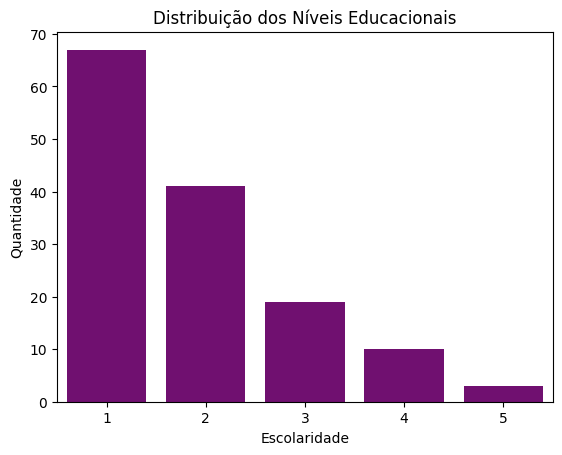

In [4]:
#verificando os niveis educacionais
sns.countplot(data=df_test, x='ed', color='purple')
plt.title('Distribuição dos Níveis Educacionais')
plt.xlabel('Escolaridade')
plt.ylabel('Quantidade')
plt.show()

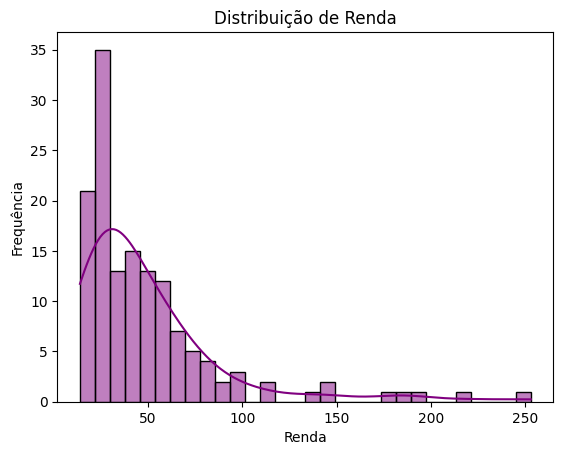

In [5]:
#analisando distribuição da renda
sns.histplot(data=df_test, x='income', bins=30, kde=True, color='purple')
plt.title('Distribuição de Renda')
plt.xlabel('Renda')
plt.ylabel('Frequência')
plt.show()

## **Formando Grupos**
Por meio dos gáficos apresentados, notamos que a maior parte tem o nível mais baixo de escolaridade e renda menor. Dado siso, queremos descobrir se o modelo está enviesado para algum lado. Para isso dividiremos nosso dados em grupos, para posterior análise.

In [ ]:
#criando grupos de renda
df_test['income_group'] = pd.qcut(
    df_test['income'],
    q=3,
    labels=['Baixa', 'Média', 'Alta']
)

In [29]:
df_test['income_group'].unique()

['Baixa', 'Alta', 'Média']
Categories (3, str): ['Baixa' < 'Média' < 'Alta']

In [35]:
df_test['ed'].unique()

array([1, 2, 4, 3, 5])

## **Porcentagem Clientes Não Confiáveis Por Grupo**
Com os grupos feitos, queremos observar se houve diferença entre as porcentagens de inadimplmentes por grupo, considerando os resultados previstos pelo modelo ('y_pred') e os reais ('y_true').

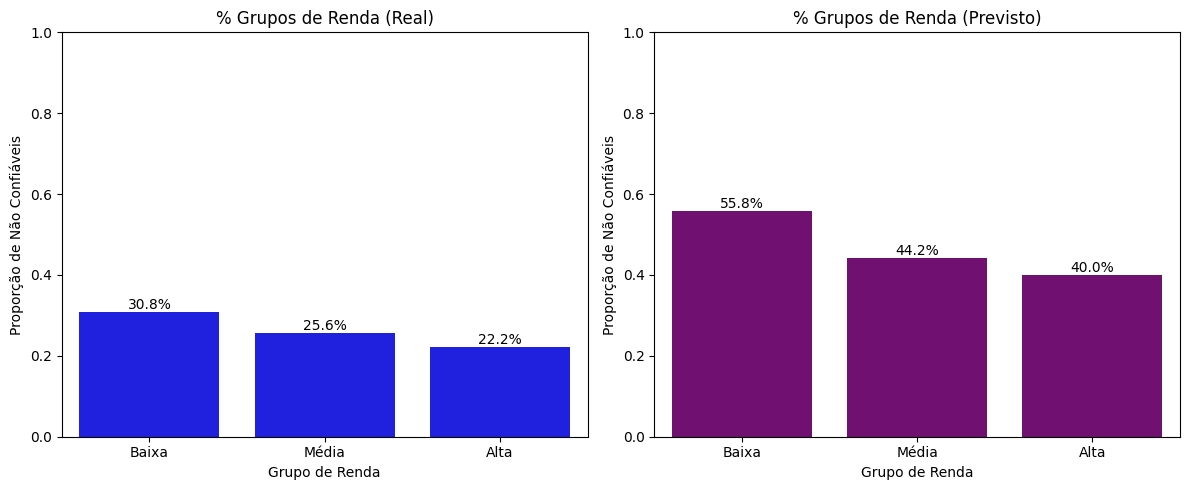

In [56]:
# calcular dados
perc_pred = df_test.groupby('income_group')['y_pred'].mean().reset_index()
perc_true = df_test.groupby('income_group')['y_true'].mean().reset_index()

# criar figura com 2 gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 🔹 Gráfico real
sns.barplot(x='income_group', y='y_true', data=perc_true, ax=axes[0], color='blue')

for i, v in enumerate(perc_true['y_true']):
    axes[0].text(i, v, f"{v:.1%}", ha='center', va='bottom')

axes[0].set_title('% Grupos de Renda (Real)')
axes[0].set_ylabel('Proporção de Não Confiáveis')
axes[0].set_xlabel('Grupo de Renda')
axes[0].set_ylim(0,1)

# 🔹 Gráfico previsto
sns.barplot(x='income_group', y='y_pred', data=perc_pred, ax=axes[1], color='purple')

for i, v in enumerate(perc_pred['y_pred']):
    axes[1].text(i, v, f"{v:.1%}", ha='center', va='bottom')

axes[1].set_title('% Grupos de Renda (Previsto)')
axes[1].set_ylabel('Proporção de Não Confiáveis')
axes[1].set_xlabel('Grupo de Renda')
axes[1].set_ylim(0,1)


plt.tight_layout()
plt.show()

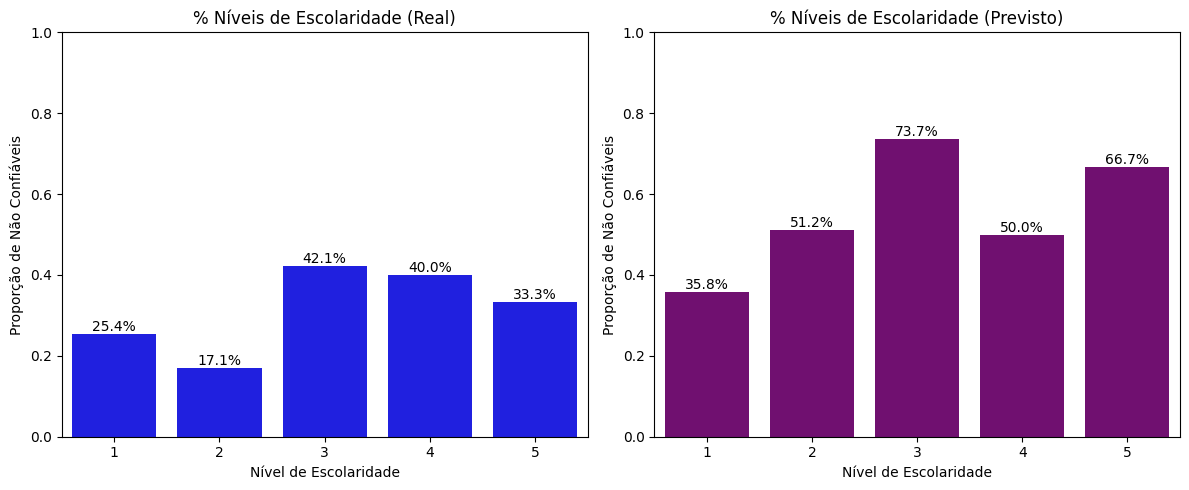

In [55]:
# calcular dados
perc_pred = df_test.groupby('ed')['y_pred'].mean().reset_index()
perc_true = df_test.groupby('ed')['y_true'].mean().reset_index()

# criar figura com 2 gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 🔹 Gráfico real
sns.barplot(x='ed', y='y_true', data=perc_true, ax=axes[0], color='blue')

for i, v in enumerate(perc_true['y_true']):
    axes[0].text(i, v, f"{v:.1%}", ha='center', va='bottom')

axes[0].set_title('% Níveis de Escolaridade (Real)')
axes[0].set_ylabel('Proporção de Não Confiáveis')
axes[0].set_xlabel('Nível de Escolaridade')
axes[0].set_ylim(0,1)

# 🔹 Gráfico previsto
sns.barplot(x='ed', y='y_pred', data=perc_pred, ax=axes[1], color='purple')

for i, v in enumerate(perc_pred['y_pred']):
    axes[1].text(i, v, f"{v:.1%}", ha='center', va='bottom')

axes[1].set_title('% Níveis de Escolaridade (Previsto)')
axes[1].set_ylabel('Proporção de Não Confiáveis')
axes[1].set_xlabel('Nível de Escolaridade')
axes[1].set_ylim(0,1)


plt.tight_layout()
plt.show()

A análise comparativa entre os valores reais e previstos revela que o modelo não apenas reproduz as diferenças existentes nos dados, mas também as amplifica.

* No caso da renda, observa-se que o modelo eleva a proporção de clientes classificados como não confiáveis em todos os grupos. Embora o aumento seja mais expressivo em termos absolutos para o grupo de baixa renda, o crescimento ocorre de forma generalizada, indicando que o modelo tende a superestimar o risco de inadimplência independentemente do grupo analisado.

* Para a variável de escolaridade, a distorção é ainda mais evidente, com determinados níveis apresentando taxas previstas de inadimplência muito superiores às observadas nos dados reais.

Esses resultados sugerem que o modelo pode estar **introduzindo** ou **intensificando vieses**, penalizando desproporcionalmente certos grupos.

## **Matriz de Confusão - Grupo de Renda**

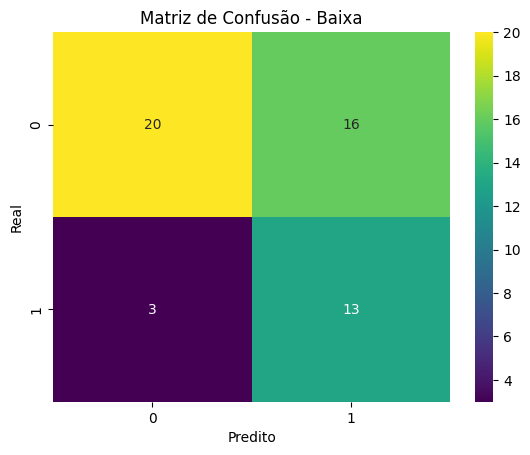

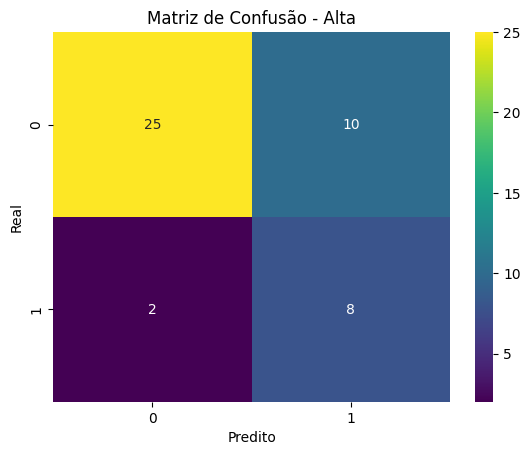

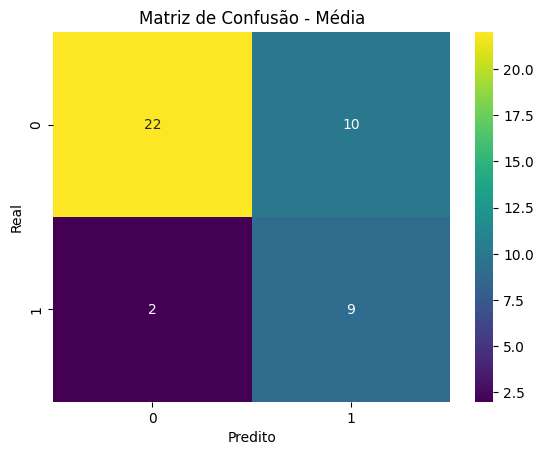

In [57]:
for group in df_test['income_group'].unique():
    df_g = df_test[df_test['income_group'] == group]
    
    cm = confusion_matrix(df_g['y_true'], df_g['y_pred'])
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
    plt.title(f'Matriz de Confusão - {group}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

## **Matriz de Confusão - Nível Educacional**

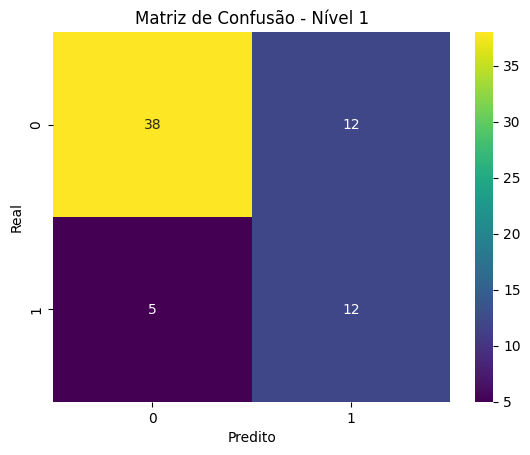

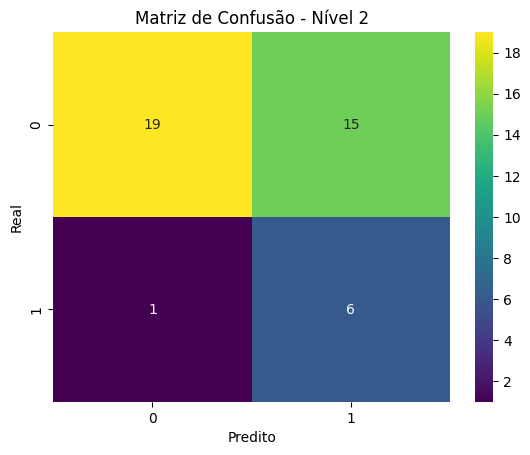

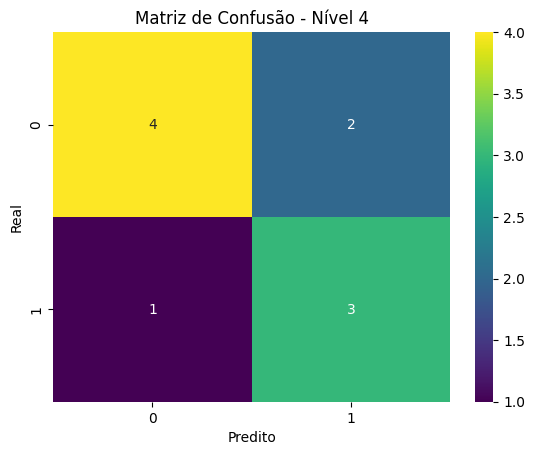

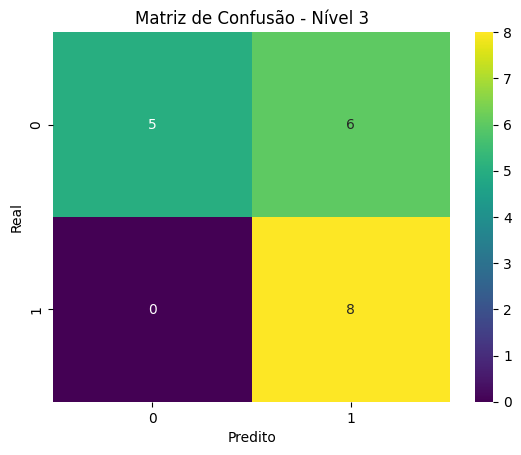

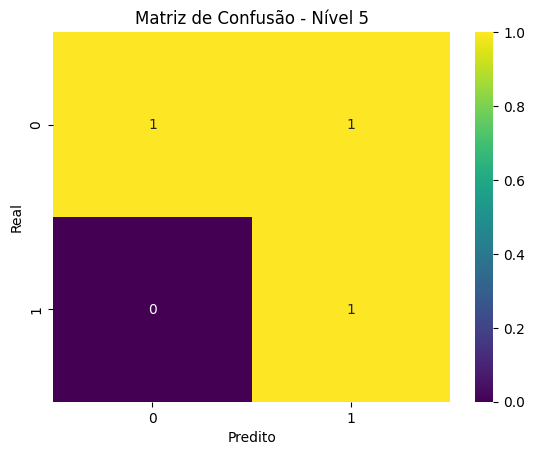

In [59]:
for group in df_test['ed'].unique():
    df_g = df_test[df_test['ed'] == group]
    
    cm = confusion_matrix(df_g['y_true'], df_g['y_pred'])
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
    plt.title(f'Matriz de Confusão - Nível {group}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()